In [1]:
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from algos.hotdeck import create_country_bands_df, hotdeck_imputation_multiple_targets, hotdeck_imputation_weighted
from algos.error_calc import evaluate_imputation
from algos.relative_error import run_relative_error_analysis

In [2]:
config = {
    'n_bands': 4,
    'random_state': 42,
    'donor_threshold': 1,
    'output_dir': 'hotdeck_results',
    'banding_min_non_null': 20,
}

os.makedirs(config['output_dir'], exist_ok=True)

#### Loading Data

In [3]:
# Load your datasets (adjust filenames as needed)
original_df = pd.read_csv('ceda_cleaned.csv')
masked_df = pd.read_csv('ceda_masked_15pct_seed123.csv')  # Your pre-masked dataset
covariates_df = pd.read_csv('country_indicator_latest_values.csv')

print(f"✓ Original data: {original_df.shape[0]} rows, {original_df.shape[1]} columns")
print(f"✓ Masked data:   {masked_df.shape[0]} rows, {masked_df.shape[1]} columns")
print(f"✓ Covariates:    {covariates_df.shape[0]} rows, {covariates_df.shape[1]} columns")

✓ Original data: 149 rows, 402 columns
✓ Masked data:   149 rows, 402 columns
✓ Covariates:    217 rows, 11 columns


#### Identifying target columns

In [4]:
# Get ALL numeric columns except Country and Country Code
all_numeric_cols = original_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Country', 'Country Code']
target_columns = [col for col in all_numeric_cols if col not in exclude_cols]

print(f"✓ Found {len(target_columns)} numeric columns to impute")
print(f"  First 10 columns: {target_columns[:10]}")
if len(target_columns) > 10:
    print(f"  ... and {len(target_columns) - 10} more")

# Check which of these columns actually have missing values in masked data
columns_with_missing = []
for col in target_columns:
    if col in masked_df.columns:
        missing_count = masked_df[col].isna().sum()
        if missing_count > 0:
            columns_with_missing.append(col)

print(f"\n✓ Columns with missing values: {len(columns_with_missing)}")
print(f"  First 10: {columns_with_missing[:10]}")
if len(columns_with_missing) > 10:
    print(f"  ... and {len(columns_with_missing) - 10} more")

✓ Found 400 numeric columns to impute
  First 10 columns: ['1111A0', '1111B0', '111200', '111300', '111400', '111900', '112120', '1121A0', '112300', '112A00']
  ... and 390 more

✓ Columns with missing values: 400
  First 10: ['1111A0', '1111B0', '111200', '111300', '111400', '111900', '112120', '1121A0', '112300', '112A00']
  ... and 390 more


#### Creating banded covariates

In [5]:
bands_df = create_country_bands_df(
    covariate_df=covariates_df,
    banding_columns=None,  # Use ALL numeric columns
    n_bands=config['n_bands'],
    band_labels=None,
    min_non_null=config['banding_min_non_null']
)

# Save banded data
bands_output_path = os.path.join(config['output_dir'], 'country_bands.xlsx')
bands_df.to_excel(bands_output_path, index=False)
print(f"\n✓ Banded covariates saved to: {bands_output_path}")

Found 9 numeric covariates to potentially band:
  Fossil fuel energy consumption (% of total): 149 non-null values
  Energy use (kg of oil equivalent per capita): 149 non-null values
  GDP per capita, PPP (constant 2021 international $): 199 non-null values
  Manufacturing, value added (% of GDP): 194 non-null values
  Exports of goods and services (% of GDP): 183 non-null values
  Access to electricity (% of population): 215 non-null values
  Rail lines (total route-km): 68 non-null values
  Population, total: 217 non-null values
  Urban population (% of total population): 217 non-null values

Creating bands (1-4) for covariates with ≥20 non-null values:
    pd.qcut failed, using percentile-based binning: Bin labels must be one fewer than the number of bin edges
  Fossil fuel energy consumption (% of total): ✗ Banding failed - Only 1 unique bins after de-duplication
  Energy use (kg of oil equivalent per capita): ✓ Successfully banded
     Bins: [68.95, 617.48, 1481.22, 2850.94, 16683

#### Hot Deck Imputation

In [6]:
# Run imputation on ALL columns that have missing values
imputed_df, imputation_log = hotdeck_imputation_multiple_targets(
    target_df=masked_df,
    bands_df=bands_df,
    target_columns=columns_with_missing,  # Only impute columns that need it
    match_vars=None,
    random_state=config['random_state'],
    donor_threshold=config['donor_threshold'],
    verbose=True
)

# Save imputed results
imputed_output_path = os.path.join(config['output_dir'], 'imputed_results.xlsx')
imputed_df.to_excel(imputed_output_path, index=False)
print(f"\n✓ Imputed data saved to: {imputed_output_path}")


Target columns to impute: ['1111A0', '1111B0', '111200', '111300', '111400', '111900', '112120', '1121A0', '112300', '112A00', '113000', '114000', '115000', '211000', '212100', '212230', '2122A0', '212310', '2123A0', '213111', '21311A', '221100', '221200', '221300', '233210', '233262', '230301', '230302', '2332A0', '233412', '2334A0', '233230', '2332D0', '233240', '233411', '2332C0', '321100', '321200', '321910', '3219A0', '327100', '327200', '327310', '327320', '327330', '327390', '327400', '327910', '327991', '327992', '327993', '327999', '331110', '331200', '331313', '331410', '331420', '331490', '331510', '331520', '332114', '33211A', '332119', '332200', '332310', '332320', '332410', '332420', '332430', '332500', '332600', '332710', '332720', '332800', '332913', '33291A', '332991', '332996', '33299A', '332999', '333111', '333112', '333120', '333130', '333242', '33329A', '333314', '333316', '333318', '333414', '333415', '333413', '333511', '333514', '333517', '33351B', '333611', '33

KeyboardInterrupt: 

#### Evaluation

In [ ]:
eval_df = evaluate_imputation(
    original_df, 
    imputed_df, 
    masked_df, 
    columns_with_missing, 
    config
)

Columns with imputed values: 400
Calculating evaluation metrics...
✓ Evaluation metrics saved to: hotdeck_results\evaluation_metrics_all_columns.xlsx

Evaluation Summary:
  Columns evaluated: 400
  Total imputed values across all columns: 8993
  Total successfully evaluated: 8930
  Average MAE: 0.295457
  Average RMSE: 0.418869

Top 5 best performing columns (lowest MAE):
  524113: MAE=0.036233 (n=22)
  531HSO: MAE=0.042387 (n=20)
  611B00: MAE=0.045989 (n=24)
  S00500: MAE=0.053232 (n=16)
  52A000: MAE=0.059786 (n=17)

Top 5 worst performing columns (highest MAE):
  327310: MAE=7.956391 (n=26)
  221100: MAE=3.535587 (n=18)
  327400: MAE=2.593027 (n=16)
  562000: MAE=2.011780 (n=23)
  481000: MAE=0.980813 (n=17)

Columns with remaining missing values:
  ✅ All missing values were successfully imputed!


#### Summary Log

In [ ]:
# Save summary log
log_summary = []
for col, log_data in imputation_log.items():
    log_summary.append({
        'column': col,
        'n_imputed': log_data['n_imputed'],
        'success_rate': log_data['success_rate'],
        'avg_match_donors': log_data.get('avg_match_donors', 0),
        'exact_matches': log_data.get('fallback_counts', {}).get('exact', 0),
        'partial_matches': log_data.get('fallback_counts', {}).get('partial', 0),
        'fallbacks': log_data.get('fallback_counts', {}).get('band_mean', 0) + 
                    log_data.get('fallback_counts', {}).get('global_mean', 0),
        'unique_donors': len(log_data.get('donor_usage', {}))
    })

log_summary_df = pd.DataFrame(log_summary)
log_path = os.path.join(config['output_dir'], 'imputation_summary.csv')
log_summary_df.to_csv(log_path, index=False)
print(f"✓ Imputation summary saved to: {log_path}")

✓ Imputation summary saved to: hotdeck_results\imputation_summary.csv


#### Report

In [ ]:
# Before vs After comparison
print("\nMissing Values Summary:")
print("-" * 40)

# Get all numeric columns that exist in both datasets
all_columns = set(masked_df.columns).intersection(set(imputed_df.columns))
numeric_cols = [col for col in all_columns 
                if col not in ['Country', 'Country Code'] 
                and pd.api.types.is_numeric_dtype(masked_df[col])]

# Create summary table
summary_data = []
for col in numeric_cols[:20]:  # Show first 20 for brevity
    missing_before = masked_df[col].isna().sum() if col in masked_df.columns else 0
    missing_after = imputed_df[col].isna().sum() if col in imputed_df.columns else 0
    
    summary_data.append({
        'Column': col,
        'Missing_Before': missing_before,
        'Missing_After': missing_after,
        'Imputed': missing_before - missing_after,
        'Still_Missing': missing_after
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Imputed', ascending=False)

print(summary_df.to_string(index=False))

# Save summary
summary_path = os.path.join(config['output_dir'], 'missing_values_summary.xlsx')
summary_df.to_excel(summary_path, index=False)
print(f"\n✓ Missing values summary saved to: {summary_path}")


Missing Values Summary:
----------------------------------------
Column  Missing_Before  Missing_After  Imputed  Still_Missing
332119              26              0       26              0
321910              26              0       26              0
21311A              26              0       26              0
336992              25              0       25              0
335999              24              0       24              0
611100              24              0       24              0
212310              23              0       23              0
336310              23              0       23              0
333112              23              0       23              0
333514              22              0       22              0
233210              22              0       22              0
311420              22              0       22              0
813100              22              0       22              0
1111A0              21              0       21              0
3364

#### Final Summary

In [ ]:
print("\n" + "="*70)
print("WORKFLOW COMPLETE - ALL COLUMNS PROCESSED")
print("="*70)

print(f"\nSUMMARY:")
print(f"  Total columns in dataset: {len(imputed_df.columns)}")
print(f"  Numeric columns processed: {len(numeric_cols)}")
print(f"  Columns with missing values: {len(columns_with_missing)}")
print(f"  Columns actually imputed: {len(imputation_log)}")
print(f"  Total missing values before: {masked_df[numeric_cols].isna().sum().sum()}")
print(f"  Total missing values after: {imputed_df[numeric_cols].isna().sum().sum()}")
print(f"  Total values imputed: {masked_df[numeric_cols].isna().sum().sum() - imputed_df[numeric_cols].isna().sum().sum()}")

print(f"\nOUTPUT FILES:")
print(f"  1. {config['output_dir']}/country_bands.xlsx - Banded covariates")
print(f"  2. {config['output_dir']}/ceda_cleaned_complete.xlsx - Fully imputed dataset (Excel)")
print(f"  3. {config['output_dir']}/ceda_cleaned_complete.csv - Fully imputed dataset (CSV)")
print(f"  4. {config['output_dir']}/imputation_summary.csv - Imputation statistics per column")
print(f"  5. {config['output_dir']}/evaluation_metrics_all_columns.xlsx - Accuracy metrics")
print(f"  6. {config['output_dir']}/missing_values_summary.xlsx - Before/after comparison")


WORKFLOW COMPLETE - ALL COLUMNS PROCESSED

SUMMARY:
  Total columns in dataset: 402
  Numeric columns processed: 400
  Columns with missing values: 400
  Columns actually imputed: 400
  Total missing values before: 8993
  Total missing values after: 0
  Total values imputed: 8993

OUTPUT FILES:
  1. hotdeck_results/country_bands.xlsx - Banded covariates
  2. hotdeck_results/ceda_cleaned_complete.xlsx - Fully imputed dataset (Excel)
  3. hotdeck_results/ceda_cleaned_complete.csv - Fully imputed dataset (CSV)
  4. hotdeck_results/imputation_summary.csv - Imputation statistics per column
  5. hotdeck_results/evaluation_metrics_all_columns.xlsx - Accuracy metrics
  6. hotdeck_results/missing_values_summary.xlsx - Before/after comparison


#### Relative Error

RELATIVE ERROR ANALYSIS
Analyzing relative error for 400 columns...

✓ Relative error analysis saved to: hotdeck_results\relative_error_analysis.xlsx

RELATIVE ERROR SUMMARY

Overall MAPE: 53.3%
Median MAPE: 48.5%
Overall sMAPE: 42.3%

Accuracy thresholds:
  Within 10%: 18.0% of imputed values
  Within 20%: 33.2% of imputed values
  Within 50%: 68.9% of imputed values

Performance categories:
  Excellent (≤10% error): 0 columns
  Good (10-30% error): 22 columns
  Fair (30-50% error): 197 columns
  Poor (>50% error): 181 columns

⚠️  1 columns with mean < 0.1 have >50% MAPE
   This is likely due to division by very small numbers, not poor imputation

DEEP DIVE: WORST PERFORMING COLUMNS

22. Column: 221100
   MAPE: 169.6%
   MAE: 3.5356
   Mean true value: 3.9256
   Imputed count: 18

   Value distribution:
     Original - min: 0.1147, max: 19.2842, median: 3.0085
     Imputed  - min: 0.8285, max: 9.4404, median: 3.7184
   Data density: 100.0% of countries have non-null values
   Outlier

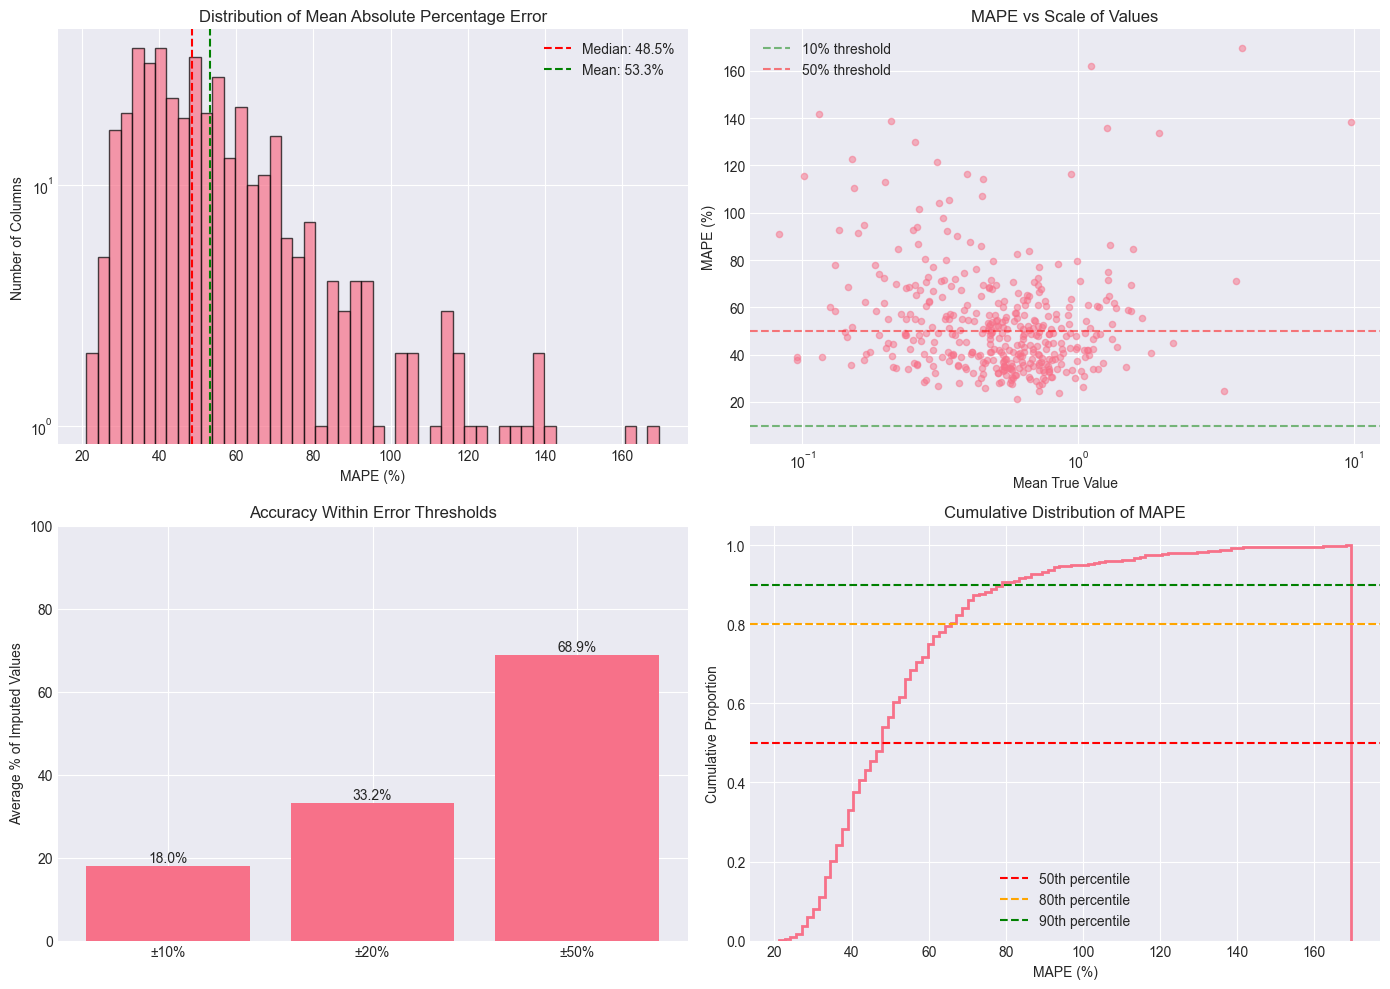

✓ Visualization saved to: hotdeck_results\relative_error_distributions.png


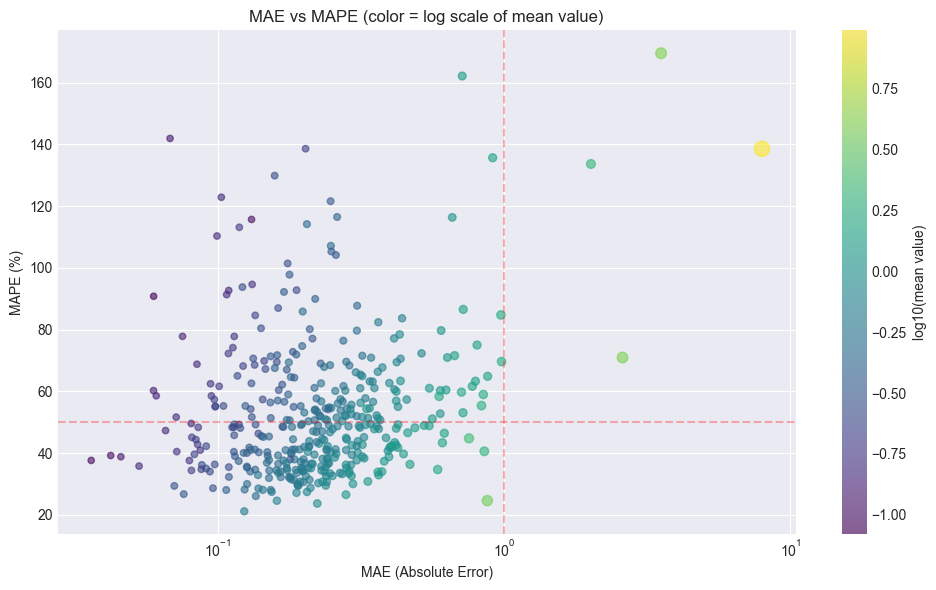

✓ Scatter plot saved to: hotdeck_results\mae_vs_mape_scatter.png

ANALYSIS OF YOUR SPECIFIC WORST COLUMNS

327310:
  MAPE: 138.6%
  Mean true value: 9.7952
  MAE: 7.9564
  Within 20%: 34.6% of imputations
  10% error would be MAE=0.9795
  Actual MAE=7.9564 - ⚠️ Needs review

221100:
  MAPE: 169.6%
  Mean true value: 3.9256
  MAE: 3.5356
  Within 20%: 11.1% of imputations
  10% error would be MAE=0.3926
  Actual MAE=3.5356 - ⚠️ Needs review

327400:
  MAPE: 71.0%
  Mean true value: 3.7360
  MAE: 2.5930
  Within 20%: 18.8% of imputations
  10% error would be MAE=0.3736
  Actual MAE=2.5930 - ⚠️ Needs review

562000:
  MAPE: 133.7%
  Mean true value: 1.9699
  MAE: 2.0118
  Within 20%: 26.1% of imputations
  10% error would be MAE=0.1970
  Actual MAE=2.0118 - ⚠️ Needs review

481000:
  MAPE: 69.6%
  Mean true value: 1.5564
  MAE: 0.9808
  Within 20%: 17.6% of imputations
  10% error would be MAE=0.1556
  Actual MAE=0.9808 - ⚠️ Needs review

TOP 10 WORST COLUMNS BY RELATIVE ERROR
     column

In [ ]:
rel_df = run_relative_error_analysis(
    original_df=original_df,
    imputed_df=imputed_df, 
    masked_df=masked_df,
    output_dir='hotdeck_results'
)

# Quick view of the worst columns by relative error
print("\n" + "="*70)
print("TOP 10 WORST COLUMNS BY RELATIVE ERROR")
print("="*70)
print(rel_df[['column', 'MAPE_%', 'mean_true', 'MAE', 'within_20%']].head(10).to_string())


In [ ]:
# # Load your covariates data
# covariates_df = pd.read_csv('country_indicator_latest_values.csv')

# # 1. Create banded covariates
# bands_df = create_country_bands_df(
#     covariate_df=covariates_df,
#     banding_columns=None,  # Use ALL numeric columns
#     n_bands=4,
#     band_labels=None,  # Will use 1, 2, 3, 4
#     min_non_null=20
# )

# # Check the output
# print("\nChecking data types:")
# for col in bands_df.columns:
#     if col not in ['Country Name', 'Country Code']:
#         print(f"  {col}: {bands_df[col].dtype}")

# # List successfully banded integer columns
# banded_int_cols = [col for col in bands_df.columns 
#                    if col not in ['Country Name', 'Country Code'] 
#                    and pd.api.types.is_integer_dtype(bands_df[col])]

# print(f"\nSuccessfully banded integer columns ({len(banded_int_cols)}):")
# for col in banded_int_cols:
#     unique_vals = bands_df[col].dropna().unique()
#     print(f"  {col}: bands {sorted([int(v) for v in unique_vals if pd.notna(v)])}")

# # Sample of banded data
# print("\nSample of banded data (first 5 countries):")
# sample_cols = ['Country Name', 'Country Code'] + banded_int_cols[:3]
# print(bands_df[sample_cols].head())

Found 9 numeric covariates to potentially band:
  Fossil fuel energy consumption (% of total): 149 non-null values
  Energy use (kg of oil equivalent per capita): 149 non-null values
  GDP per capita, PPP (constant 2021 international $): 199 non-null values
  Manufacturing, value added (% of GDP): 194 non-null values
  Exports of goods and services (% of GDP): 183 non-null values
  Access to electricity (% of population): 215 non-null values
  Rail lines (total route-km): 68 non-null values
  Population, total: 217 non-null values
  Urban population (% of total population): 217 non-null values

Creating bands (1-4) for covariates with ≥20 non-null values:
    pd.qcut failed, using percentile-based binning: Bin labels must be one fewer than the number of bin edges
  Fossil fuel energy consumption (% of total): ✗ Banding failed - Only 1 unique bins after de-duplication
  Energy use (kg of oil equivalent per capita): ✓ Successfully banded
     Bins: [68.95, 617.48, 1481.22, 2850.94, 16683

#### Weighted hot deck imputation (w correlation coefficient)

In [ ]:
imputed_df, log = hotdeck_imputation_weighted(
    target_df=masked_df,
    bands_df=bands_df,
    original_df=original_df,  # 🔴 CRITICAL - provides correlation weights
    target_columns=None,      # Auto-detect all numeric columns
    weight_threshold=0.20,    # Only use covariates with r ≥ 0.20
    random_state=42
)

Target columns to impute: 400
Number of countries in target data: 149
Number of countries in bands data: 217
Merged data shape: (149, 412)
Missing values in merged data: 8993

Using 8 banded covariates for matching

Calculating correlation weights from original data...

  111200 top predictors:
    Energy use (kg of oil equivalent per capita): weight=0.535
    Access to electricity (% of population): weight=0.465

  111300 top predictors:
    Energy use (kg of oil equivalent per capita): weight=0.296
    Rail lines (total route-km): weight=0.292
    Access to electricity (% of population): weight=0.234

  111400 top predictors:
    Energy use (kg of oil equivalent per capita): weight=1.000

Processing: 1111A0
Missing values: 21
Available donors: 128
Imputed: 21 values
Unique donors used: 2
Fallback methods: {'exact': 2, 'weighted': 0, 'band_mean': 0, 'global_mean': 19}

Processing: 1111B0
Missing values: 30
Available donors: 119
Imputed: 30 values
Unique donors used: 4
Fallback methods

In [ ]:
eval_df = evaluate_imputation(
    original_df, 
    imputed_df, 
    masked_df, 
    columns_with_missing, 
    config
)

Columns with imputed values: 400
Calculating evaluation metrics...


C:\Users\ryank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ryank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✓ Evaluation metrics saved to: hotdeck_results\evaluation_metrics_all_columns.xlsx

Evaluation Summary:
  Columns evaluated: 400
  Total imputed values across all columns: 8993
  Total successfully evaluated: 8930
  Average MAE: 0.285415
  Average RMSE: 0.396820

Top 5 best performing columns (lowest MAE):
  524113: MAE=0.031075 (n=22)
  5241XX: MAE=0.032762 (n=24)
  524200: MAE=0.035253 (n=15)
  561300: MAE=0.049346 (n=27)
  531HSO: MAE=0.054049 (n=20)

Top 5 worst performing columns (highest MAE):
  327310: MAE=6.056829 (n=26)
  221100: MAE=3.978469 (n=18)
  562000: MAE=2.148303 (n=23)
  327400: MAE=1.446622 (n=16)
  331110: MAE=1.396887 (n=9)

Columns with remaining missing values:
  ✅ All missing values were successfully imputed!
